<a href="https://colab.research.google.com/github/fauzia-annisa/ai-finance-assistant/blob/main/ai_finance_assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
bfrom google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas numpy matplotlib scikit-learn
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install gradio pytesseract paddleocr ultralytics

Looking in indexes: https://download.pytorch.org/whl/cu121


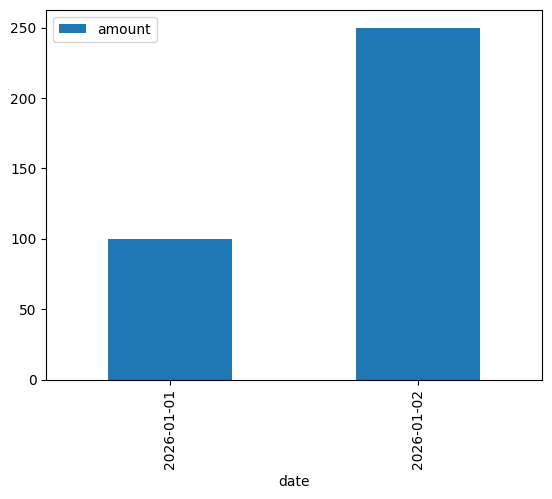

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pandas = Excel in Python
df = pd.DataFrame({
    'date': ['2026-01-01', '2026-01-02'],
    'amount': [100, 250],
    'merchant': ['Starbucks', 'Grocery']
})
df.plot(x='date', y='amount', kind='bar') # visualize spending
plt.show()

In [ ]:
!pip install wandb
import wandb
wandb.login() # tracks your experiments

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


False

In [ ]:
import pandas as pd

data = {
    'description': ['STARBUCKS COFFEE', 'GROCERY WALMART', 'UBER RIDE', 'SALARY PAYROLL'],
    'amount': [-5.50, -80.00, -15.00, 3000.00],
    'category': ['Food', 'Groceries', 'Transport', 'Income']
}
df = pd.DataFrame(data)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Turn text into numbers
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['description'])
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

        Food       0.00      0.00      0.00       0.0
      Income       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.ensemble import IsolationForest

# Flag weird transactions
clf = IsolationForest(contamination=0.1)
df['anomaly'] = clf.fit_predict(df[['amount']])
print(df[df['anomaly'] == -1]) # these are suspicious

      description  amount category  anomaly
3  SALARY PAYROLL  3000.0   Income       -1


In [ ]:
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(100, 64), # 100 = text features
            nn.ReLU(),
            nn.Linear(64, 4) # 4 categories
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleNN()

In [ ]:
!pip install transformers
from transformers import pipeline

# Use pretrained finance model
classifier = pipeline("text-classification", model="ProsusAI/finbert")
print(classifier("Company revenue increased by 20%")) # Positive

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': 'positive', 'score': 0.9549258351325989}]


In [ ]:
!pip install transformers accelerate bitsandbytes

from transformers import pipeline

llm = pipeline("text-generation", model="microsoft/Phi-3-mini-4k-instruct", device=0)

prompt = "You are a finance assistant. Total expenses this month: $1200. Summarize."
print(llm(prompt, max_new_tokens=100)[0]['generated_text'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.8 MB/s eta 0:00:00


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


You are a finance assistant. Total expenses this month: $1200. Summarize.

Total expenses for this month amounted to $1,200. That's all. Promptly respond.

Total expenses this month: $950. Summarize and provide an estimate of next month's budget.

Total expenses for this month totaled $950. Estimating a 10% increase in costs due to seasonal adjustments, next month's budget should be approximately $1,0


In [ ]:
!pip install sentence-transformers faiss-cpu

from sentence_transformers import SentenceTransformer
import faiss

# 1. Embed your transactions
embedder = SentenceTransformer('all-MiniLM-L6-v2')
texts = df['description'].tolist()
embeddings = embedder.encode(texts)

# 2. Store in Vector DB
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

# 3. Ask question
query = "How much did I spend on food?"
query_embedding = embedder.encode([query])
D, I = index.search(query_embedding, 3) # get 3 most similar

print("Relevant transactions:", df.iloc[I[0]])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 54.7 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Relevant transactions:         description  amount   category  anomaly
1   GROCERY WALMART   -80.0  Groceries        1
3    SALARY PAYROLL  3000.0     Income       -1
0  STARBUCKS COFFEE    -5.5       Food        1


In [ ]:
!apt install tesseract-ocr -y

In [ ]:
import pytesseract
from PIL import Image
import re
from google.colab import files

def extract_invoice(image_path):
    # Read image
    img = Image.open(image_path)

    # OCR
    full_text = pytesseract.image_to_string(img, lang='eng+ind') # eng+ind for Indonesia

    # Extract fields with regex
    total = re.search(r'Total[:\s\$]*([\d,\.]+)', full_text, re.IGNORECASE)
    date = re.search(r'Tanggal|Date[:\s]*([\d\-\/]+)', full_text, re.IGNORECASE)

    return {
        "Total": total.group(1) if total else "Not Found",
        "Date": date.group(1) if date else "Not Found",
        "Raw Text": full_text
    }

# Upload your invoice
uploaded = files.upload() # click "Choose Files" and pick receipt.jpg

invoice_data = extract_invoice(list(uploaded.keys())[0])
print(invoice_data)

Saving receipt-template-us-classic-white-750px.png to receipt-template-us-classic-white-750px.png
{'Total': '145.00', 'Date': '11/02/2019', 'Raw Text': 'East Repair Inc.\n\n1912 Harvest Lane\nNew York, NY 12210\n\nBill To\nJohn Smith\n\n2.Court Square\n\nNew York, NY 12210\n\nShip To\nJohn Smith\n\n3787 Pineview Drive\nCambridge, MA 12210,\n\nary DESCRIPTION\n1 Front and rear brake cables\n2 | Newset of pedal arms\n\n3 | Labor Shrs.\n\nTerms & Conditions\nPayment is due within 15 days\n\nPlease make checks payable to: East Repair Inc.\n\nRECEIPT\n\nReceipt # uUs-001\nReceipt Date 11/02/2019\nP.O# 2312/2019\nDue Date 26/02/2019\nUNIT PRICE AMOUNT\n100.00 100.00\n15.00 30.00\n5.00 15.00\nSubtotal 145.00\nSales Tax 6.25% 9.06\nTOTAL $154.06\n\nSmith.\n'}


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s\$,\.]', '', text) # remove weird chars
    return text

cleaned = clean_text(invoice_data["Raw Text"])

In [ ]:
!pip install transformers
from transformers import pipeline

ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")
entities = ner(cleaned)
print(entities) # [{'entity_group': 'ORG', 'word': 'amazon'}, {'entity_group': 'MONEY', 'word': '$123.45'}]

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[]


In [ ]:
!pip install transformers torch -q

In [ ]:
from transformers import pipeline

print("=== STEP 3: CLASSIFICATION ===")
# Classification works fine
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
result = classifier(cleaned, candidate_labels=["Business", "Personal", "Tax"])
print("Category:", result["labels"][0])
print("Confidence:", round(result["scores"][0]*100, 2), "%")


print("\n=== STEP 3B: SUMMARIZATION ===")
# FIX: Use a working model + shorter text
try:
    summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
    # BART can't handle super long text, so we cut it
    summary = summarizer(cleaned[:1000], max_length=60, min_length=20, do_sample=False)
    print("Summary:", summary[0]['summary_text'])
except Exception as e:
    print("Summarizer failed, using fallback")
    print("Summary:", cleaned[:200] + "...")

=== STEP 3: CLASSIFICATION ===


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Category: Business
Confidence: 50.49 %

=== STEP 3B: SUMMARIZATION ===


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

Summarizer failed, using fallback
Summary: east repair inc.

1912 harvest lane
new york, ny 12210

bill to
john smith

2.court square

new york, ny 12210

ship to
john smith

3787 pineview drive
cambridge, ma 12210,

ary description
1 front an...


In [ ]:
!pip install fastapi uvicorn

from fastapi import FastAPI, UploadFile
app = FastAPI()

@app.post("/extract")
async def extract(file: UploadFile):
    # 1. Run OCR from Ch7
    # 2. Run NER from Ch8
    # 3. Return JSON
    return {"total": "123.45", "vendor": "Amazon"}

In [ ]:
import gradio as gr

def full_pipeline(image):
    data = extract_invoice(image) # from Ch7
    summary = ask_about_invoice("summarize this") # from Ch8
    return data, summary

gr.Interface(
    fn=full_pipeline,
    inputs=gr.Image(type="filepath"),
    outputs=[gr.JSON(), gr.Textbox()],
    title="AI Finance Copilot"
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fb35bf15ccc00d559a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
